# Miguel Baños Baladrón
# Pablo Díaz Blanco
### Grupo de prácticas 1.1
### Principios de Visión por Computador

# Ejercicio 1.- Segmentación de carreteras en imagen aérea de alta resolución

# Importaciones

In [3]:
!pip install pandas numpy matplotlib scikit-image scikit-learn joblib


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.0 MB 7.3 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.0 MB 11.1 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.0 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------  10.7/11.0 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 13.0 MB/s  0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- ----


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import pandas as pd
import joblib
import numpy as np
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import sobel_h, sobel_v, sobel, laplace, gaussian, difference_of_gaussians
from skimage.feature import canny
from skimage.morphology import opening, closing, disk, remove_small_objects
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, jaccard_score
import matplotlib.pyplot as plt



# Cargar y preparar datos

In [2]:
BASE_PATH = "roads" # carpeta base 
SAT_PATH = os.path.join(BASE_PATH, "sat") # subcarpeta con las fotos de satélite
GT_PATH  = os.path.join(BASE_PATH, "gt") # subcarpeta con las máscaras binarias de etiqueta

sat_images = []
gt_masks = []

# Obtenemos los nombres de los archivos ordenados para hacer coincidir imagen con etiqueta
sat_files = []
for f in os.listdir(SAT_PATH):
    sat_files.append(f)
sat_files = sorted(sat_files)

gt_files  = []
for f in os.listdir(GT_PATH):  
    gt_files.append(f)
gt_files = sorted(gt_files)

# Para cada par imagen-etiqueta, accedemos a ellos, los leemos y los añadimos a sus correspondiente lista.
for sat, gt in zip(sat_files, gt_files):
    sat_path = os.path.join(SAT_PATH, sat)
    gt_path  = os.path.join(GT_PATH, gt)
    sat_img = io.imread(sat_path)
    gt_img  = io.imread(gt_path)
    sat_images.append(sat_img)
    gt_masks.append(gt_img)

# Se transforman en arrays de numpy para operar más rápido con ellas.
sat_images = np.array(sat_images)
gt_masks   = np.array(gt_masks)

print("Datos cargados correctamente:")
print("Satélites:", sat_images.shape)
print("Máscaras:", gt_masks.shape)

Datos cargados correctamente:
Satélites: (20, 1500, 1500, 3)
Máscaras: (20, 1500, 1500)


### Nos cercioramos de que los valores de la máscara binaria sean o 0 o 1 y normalizamos a [0,1] las imágenes de satélite.

In [3]:
# Comprobamos los valores de las máscaras, las necesitamos en 0 o en 1.
print("Valores máscara original:", np.unique(gt_masks))

# Así, convertimos todo lo que es 0 en False, y lo mayor a 0 en True. Pasándolo a uint8, False pasa a 0 y True a 1, como buscamos.
gt_masks_p = (gt_masks > 0).astype(np.uint8)
print("Máscara que usaremos:", np.unique(gt_masks_p))

# Ahora con las imágenes de satélite
print("Mínimo original imágenes de satélite:", sat_images.min())
print("Máximo original imágenes de satélite:", sat_images.max())

# Las convertimos a float32 y normalizamos a [0, 1]
sat_images_p = sat_images.astype(np.float32) / 255.0

# Comprobamos
print("Mínimo procesado imágenes de satélite:", sat_images_p.min())
print("Máximo procesado imágenes de satélite:", sat_images_p.max())

Valores máscara original: [  0 255]
Máscara que usaremos: [0 1]
Mínimo original imágenes de satélite: 0
Máximo original imágenes de satélite: 255
Mínimo procesado imágenes de satélite: 0.0
Máximo procesado imágenes de satélite: 1.0


# Función para construir vectores de características

In [4]:
def extract_features(sat_images_p):
    N, H, W, _ = sat_images_p.shape

    # Canales RGB
    R = sat_images_p[:, :, :, 0]
    G = sat_images_p[:, :, :, 1]
    B = sat_images_p[:, :, :, 2]

    # Valor de gris
    gray = rgb2gray(sat_images_p)

    # Gradiente: detectar bordes (dirección y magnitud del cambio de brillo)
    grad_x = np.empty_like(gray)
    grad_y = np.empty_like(gray)

    g_smooth = gaussian(gray, sigma=1.0, channel_axis=0) # suavizado previo para evitar que el ruido afecte al gradiente
    grad_y, grad_x = np.gradient(g_smooth, axis=(1, 2))  # derivada en x (bordes verticales), derivada en y (bordes horizontales)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2) # magnitud del gradiente (bordes fuertes -> valores altos y viceversa)

    # Sobel
    sobel_x = np.empty_like(gray) # derivada en x
    sobel_y = np.empty_like(gray) # derivada en y
    sobel_mag = np.empty_like(gray) # magnitud

    for i in range(N):
        sobel_x[i] = sobel_h(gray[i]) # sobel_h aplica el filtro de Sobel horizontalmente
        sobel_y[i] = sobel_v(gray[i]) # aquí, verticalmente
        sobel_mag[i] = sobel(gray[i])  # magnitud del gradiente de Sobel

    # Laplaciano, LoG y DoG
    laplacian = np.empty_like(gray)
    log_resp  = np.empty_like(gray)
    dog_resp  = np.empty_like(gray)

    for i in range(N):
        g = gray[i]

        # Laplaciano directo
        laplacian[i] = laplace(g)

        # Laplacian of Gaussian: primero suavizo, luego laplace
        g_smooth = gaussian(g, sigma=1.0)
        log_resp[i] = laplace(g_smooth)

        # Difference of Gaussians
        dog_resp[i] = difference_of_gaussians(g, 1.0, 2.0)

    # Canny
    canny_map = np.empty_like(gray, dtype=np.float32)

    for i in range(N):
        # canny devuelve bool -> lo paso a 0/1
        c = canny(gray[i], sigma=2.0)
        canny_map[i] = c.astype(np.float32)

    # Montar diccionario final
    feature_maps = {
        "rgb": sat_images_p,
        "R": R,
        "G": G,
        "B": B,
        "gray": gray,
        "grad_x": grad_x,
        "grad_y": grad_y,
        "grad_mag": grad_mag,
        "sobel_x": sobel_x,
        "sobel_y": sobel_y,
        "sobel_mag": sobel_mag,
        "laplacian": laplacian,
        "log": log_resp,
        "dog": dog_resp,
        "canny": canny_map,
    }

    return feature_maps

# Función para formar el dataset con cualquier vector de características como entrada

In [5]:
def build_dataset(feature_maps, gt_masks_p, feature_list):
    N, H, W = gt_masks_p.shape

    feature_columns = []

    for name in feature_list:
        if name not in feature_maps:
            raise ValueError(f"Feature '{name}' no existe en feature_maps")

        fmap = feature_maps[name] 

        # Aseguramos forma (N, H, W, C_feat) siendo C_feat el número de canales de la feature
        if fmap.ndim == 3:  # (N, H, W) -> añadimos un canal
            fmap = fmap[..., np.newaxis]  # (N, H, W, 1) (Una feature escalar como el valor de gris pasa a ser una imagen con un canal, en vez de solo una imagen)
        elif fmap.ndim != 4:
            raise ValueError(f"Mapa de '{name}' tiene ndim={fmap.ndim}, esperado 3 o 4")

        # Comprobamos que coincide en tamaño espacial
        if fmap.shape[0] != N or fmap.shape[1] != H or fmap.shape[2] != W: # Mismo número de imágenes, altura y anchura
            raise ValueError(f"Feature '{name}' tiene shape {fmap.shape}, no compatible con gt_masks {gt_masks_p.shape}")

        # Aplanamos: (N, H, W, C_feat) -> (N*H*W, C_feat)
        c_feat = fmap.shape[-1]
        f_flat = fmap.reshape(N*H*W, c_feat)

        feature_columns.append(f_flat)

    # Concatenamos todas las columnas de features → (N*H*W, D_total)
    X = np.concatenate(feature_columns, axis=1)

    # Etiquetas: (N, H, W) -> (N*H*W,)
    y = gt_masks_p.reshape(-1)

    return X, y

# Dividir en train/val/test

In [6]:
N = sat_images_p.shape[0] 

indices = np.arange(N)      # [0, 1, 2, ..., 19]
np.random.seed(42)          # para que siempre salga igual
np.random.shuffle(indices)  # baraja los índices

train_idx = indices[:16]        # 16 primeros -> TRAIN
val_idx   = indices[16:18]      # 2 siguientes -> VAL
test_idx  = indices[18:20]      # 2 últimos  -> TEST

print("Índices de las imágenes de entrenamiento:", train_idx)
print("Índices de las imágenes de validación:",   val_idx)
print("Índices de las imágenes de test:",  test_idx)

Índices de las imágenes de entrenamiento: [ 0 17 15  1  8  5 11  3 18 16 13  2  9 19  4 12]
Índices de las imágenes de validación: [ 7 10]
Índices de las imágenes de test: [14  6]


In [7]:
sat_train = sat_images_p[train_idx] # imágenes de satélite de entrenamiento
sat_val   = sat_images_p[val_idx] # de validación 
sat_test  = sat_images_p[test_idx] # de test

gt_train = gt_masks_p[train_idx]
gt_val   = gt_masks_p[val_idx]
gt_test  = gt_masks_p[test_idx]

print("Train:", sat_train.shape, gt_train.shape) 
print("Val:",   sat_val.shape,   gt_val.shape)
print("Test:",  sat_test.shape,  gt_test.shape)

Train: (16, 1500, 1500, 3) (16, 1500, 1500)
Val: (2, 1500, 1500, 3) (2, 1500, 1500)
Test: (2, 1500, 1500, 3) (2, 1500, 1500)


## Función para el balanceo de clases

- El objetivo de esta función es aplicar un balanceo de clases. En los modelos en los que se quiera tener un número similar de píxeles de cada clase se pone el parámetro balanced como true. Los parámetros son:
    1. X_train: matriz de características.
    2. y_train: etiquetas de los píxeles.
    3. frac: porcentaje de píxeles utilizados para entrenamiento.
    4. balanced: si es True, se aplica el balanceo de clases.
    5. seed: semilla para que la selección aleatoria sea siempre igual.

In [8]:
def make_train_subset(X_train, y_train, frac=0.2, balanced=True, frac_pos = 0.3, seed=42):
    n_total = len(y_train)
    n_sub = int(n_total * frac)

    if not balanced:
        idx = np.random.choice(n_total, size=n_sub, replace=False)
        return X_train[idx], y_train[idx]

    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]

    n_pos_target = int(n_sub * frac_pos)
    n_neg_target = n_sub - n_pos_target

    n_pos = min(n_pos_target, len(pos_idx))
    n_neg = min(n_neg_target, len(neg_idx))

    pos_sub = np.random.choice(pos_idx, size=n_pos, replace=False)
    neg_sub = np.random.choice(neg_idx, size=n_neg, replace=False)

    idx_sub = np.concatenate([pos_sub, neg_sub])
    np.random.shuffle(idx_sub)

    return X_train[idx_sub], y_train[idx_sub]


# Métricas

In [9]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Dice (F1)": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Jaccard": jaccard_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

# Visualizar la imagen de satélite, la máscara verdadera y la predicha

In [10]:
def visualize_results(sat_image, gt_mask, pred_mask):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Imagen de Satélite")
    plt.imshow(sat_image)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Máscara Verdadera")
    plt.imshow(gt_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Máscara Predicha")
    plt.imshow(pred_mask, cmap='gray')
    plt.axis('off')

    plt.show()

# Guardar modelos

In [11]:
def save_model_and_results(model, model_name: str, metrics_test: dict, models_dir: str = "modelos_carretera", csv_path: str = "resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv"):
    
    # Guardar el modelo .joblib
    os.makedirs(models_dir, exist_ok=True)
    model_path = os.path.join(models_dir, f"{model_name}.joblib")
    joblib.dump(model, model_path)
    print(f"Modelo guardado en {model_path}")

    # Crear la fila nueva con las métricas
    new_row = {"Modelo": model_name}
    new_row.update(metrics_test)  # añade Accuracy, Precision, etc.

    # Cargar CSV si existe, si no, crearlo
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)

        # Si ya hay una fila con ese modelo, la sustituimos
        df = df[df["Modelo"] != model_name]
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    else:
        df = pd.DataFrame([new_row])

    # Guardar el CSV actualizado
    df.to_csv(csv_path, index=False)
    print(f"Resultados de test guardados/actualizados en {csv_path}")

    return df 

## Celda con las constantes e hiperparámetros

In [12]:
FRAC_TRAIN   = 0.2          
SEED         = 42           
FEATURE_LIST = [
    "rgb",
    "gray",
    "grad_mag",
    "sobel_mag",
    "laplacian",
    "log",
    "dog",
    "canny",
]

rf_hyperparams = [
    (100, 10),
    (200, 10),
    (200, 15),
    (300, 15),  
]

hgb_hyperparams = [
    (8,  0.1, 200),
    (10, 0.1, 200),
    (10, 0.05, 300),
    (12, 0.05, 300),
]


### Preparación del dataset
- Extraemos las características en base a la lista de características que nos interesen para el modelo
- Construimos el dataset con build_dataset

In [13]:
def prepare_datasets(feature_list=FEATURE_LIST):

    # Le das acceso a la función a los datos de entrenamiento, validación y test de fuera de la función
    global X_train, y_train, X_val, y_val, X_test, y_test

    feature_maps_train = extract_features(sat_train)
    feature_maps_val   = extract_features(sat_val)
    feature_maps_test  = extract_features(sat_test)

    X_train, y_train = build_dataset(feature_maps_train, gt_train, feature_list)
    X_val,   y_val   = build_dataset(feature_maps_val,   gt_val,   feature_list)
    X_test,  y_test  = build_dataset(feature_maps_test,  gt_test,  feature_list)

    print("Datasets preparado:")
    print("  X_train:", X_train.shape, " y_train:", y_train.shape)
    print("  X_val:  ", X_val.shape,   " y_val:  ", y_val.shape)
    print("  X_test: ", X_test.shape,  " y_test: ", y_test.shape)


### Creamos el dataset

In [14]:
prepare_datasets()

Datasets preparado:
  X_train: (36000000, 10)  y_train: (36000000,)
  X_val:   (4500000, 10)  y_val:   (4500000,)
  X_test:  (4500000, 10)  y_test:  (4500000,)


## Función de entrenamiento

In [15]:
def train_model(model_cls, model_name, model_kwargs=None, *, use_balanced=True, frac=FRAC_TRAIN, seed=SEED,):

    if model_kwargs is None:
        model_kwargs = {}

    global X_train, y_train, X_val, y_val, X_test, y_test

    if use_balanced:
        X_train_sub, y_train_sub = make_train_subset(
            X_train,
            y_train,
            frac=frac,
            balanced=True,
            seed=seed,
        )
    else:
        X_train_sub, y_train_sub = X_train, y_train

    model = model_cls(**model_kwargs)
    model.fit(X_train_sub, y_train_sub)

    y_train_pred = model.predict(X_train_sub)
    y_val_pred   = model.predict(X_val)
    y_test_pred  = model.predict(X_test)

    metrics_train = compute_metrics(y_train_sub, y_train_pred)
    metrics_val   = compute_metrics(y_val,      y_val_pred)
    metrics_test  = compute_metrics(y_test,     y_test_pred)

    df_global = save_model_and_results(
        model=model,
        model_name=model_name,
        metrics_test=metrics_test,
    )

    return {
        "model": model,
        "metrics_train": metrics_train,
        "metrics_val": metrics_val,
        "metrics_test": metrics_test,
        "df_global": df_global,
    }


## Bucle de entrenamiento

### Bucle de entrenamiento para recorrer los hiperparámetros de randomforest

- Lista donde guardamos los resultados de todos los modelos

In [16]:
all_model_results = []

In [17]:
for n_estimators, max_depth in rf_hyperparams:
    model_name = f"RF_n{n_estimators}_d{max_depth}"

    rf_results = train_model(
        model_cls=RandomForestClassifier,
        model_name=model_name,
        model_kwargs=dict(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1,
            random_state=SEED,
        ),
        use_balanced=True,
    )

    all_model_results.append({
        "family": "RF",
        "name": model_name,
        "model": rf_results["model"],
        "metrics_train": rf_results["metrics_train"],
        "metrics_val": rf_results["metrics_val"],
        "metrics_test": rf_results["metrics_test"],
    })

Modelo guardado en modelos_carretera\RF_n100_d10.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv
Modelo guardado en modelos_carretera\RF_n200_d10.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv
Modelo guardado en modelos_carretera\RF_n200_d15.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv
Modelo guardado en modelos_carretera\RF_n300_d15.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv


## Bucle de entrenamiento

### Bucle de entrenamiento para recorrer los hiperparámetros de randomforest

In [18]:
for max_depth, learning_rate, max_iter in hgb_hyperparams:
    model_name = f"HGB_d{max_depth}_lr{learning_rate}_it{max_iter}"

    hgb_results = train_model(
        model_cls=HistGradientBoostingClassifier,
        model_name=model_name,
        model_kwargs=dict(
            max_depth=max_depth,
            learning_rate=learning_rate,
            max_iter=max_iter,
            random_state=SEED,
        ),
        use_balanced=True,
    )

    all_model_results.append({
        "family": "HGB",
        "name": model_name,
        "model": hgb_results["model"],
        "metrics_train": hgb_results["metrics_train"],
        "metrics_val": hgb_results["metrics_val"],
        "metrics_test": hgb_results["metrics_test"],
    })

Modelo guardado en modelos_carretera\HGB_d8_lr0.1_it200.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv
Modelo guardado en modelos_carretera\HGB_d10_lr0.1_it200.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv
Modelo guardado en modelos_carretera\HGB_d10_lr0.05_it300.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv
Modelo guardado en modelos_carretera\HGB_d12_lr0.05_it300.joblib
Resultados de test guardados/actualizados en resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv


## Postprocesado

In [19]:
def postprocess_mask(mask, min_size, radius):
    mask_bool = mask.astype(bool)

    mask_clean = remove_small_objects(mask_bool, min_size=min_size)

    selem = disk(radius)
    mask_closed = closing(mask_clean, selem)

    return mask_closed.astype(np.uint8)


# Primer modelo: Sin preprocesado 

### Para ver el efecto de no preprocesar los datos y entrenar un modelo con un conjunto de datos desbalanceado, usamos un vector de características simple (valor rgb) y como modelo, un RamdonForest, por rapidez.

Modelo: RF_n100_d10


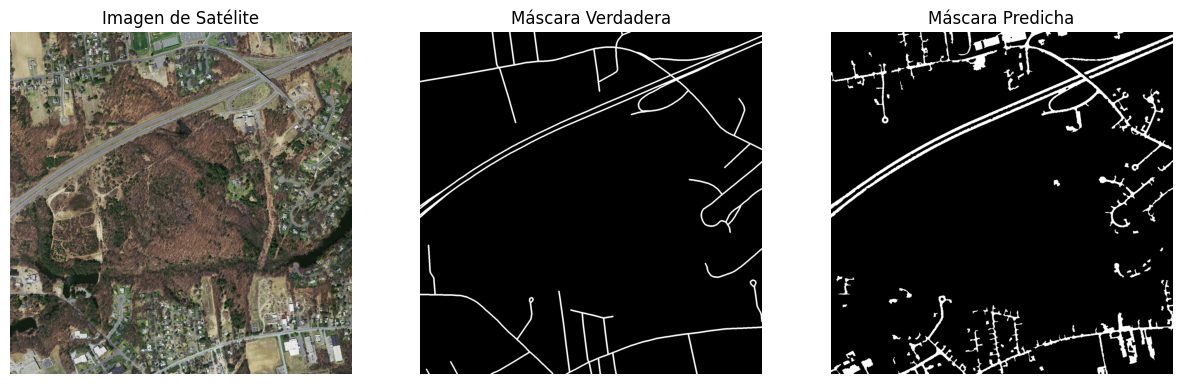

Modelo: RF_n200_d10


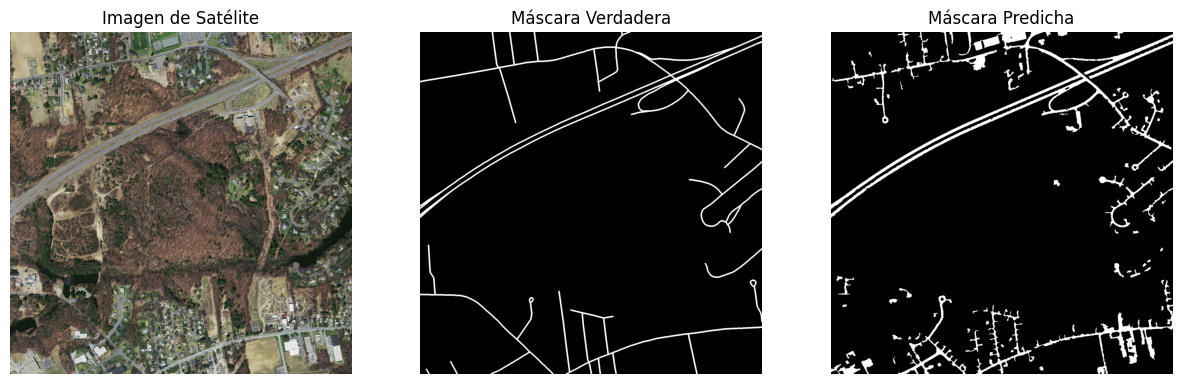

Modelo: RF_n200_d15


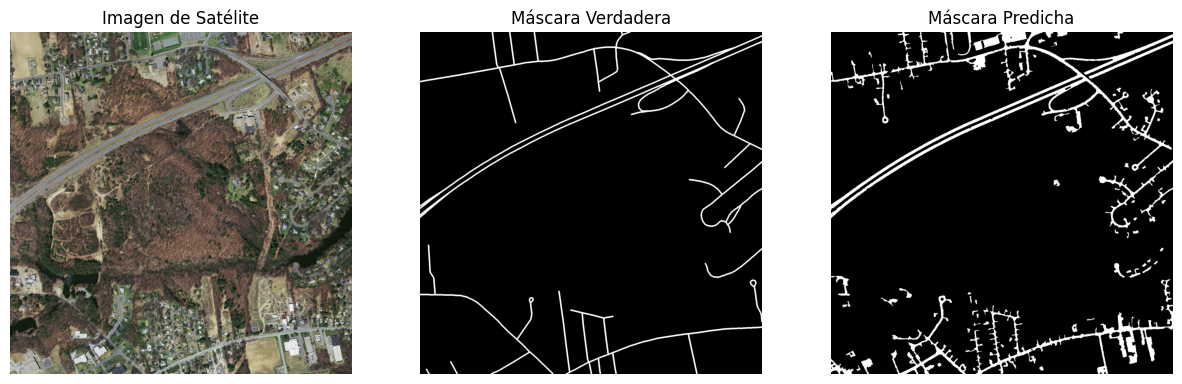

Modelo: RF_n300_d15


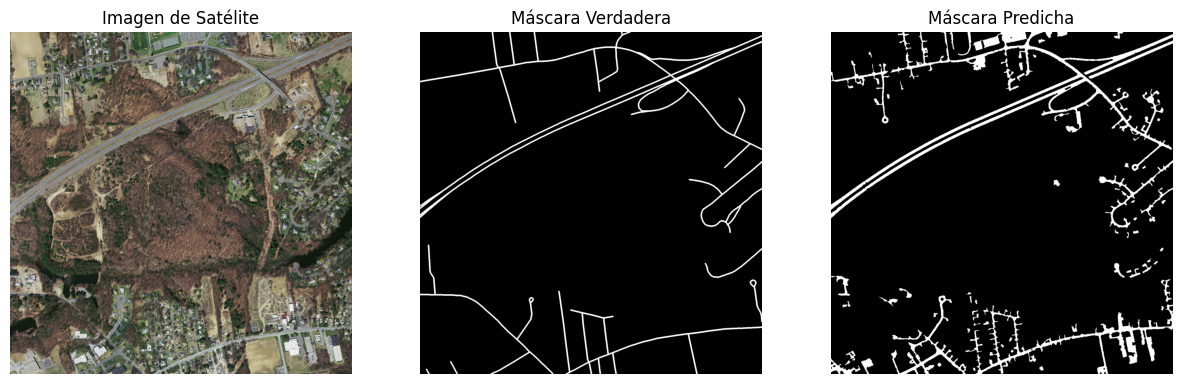

Modelo: HGB_d8_lr0.1_it200


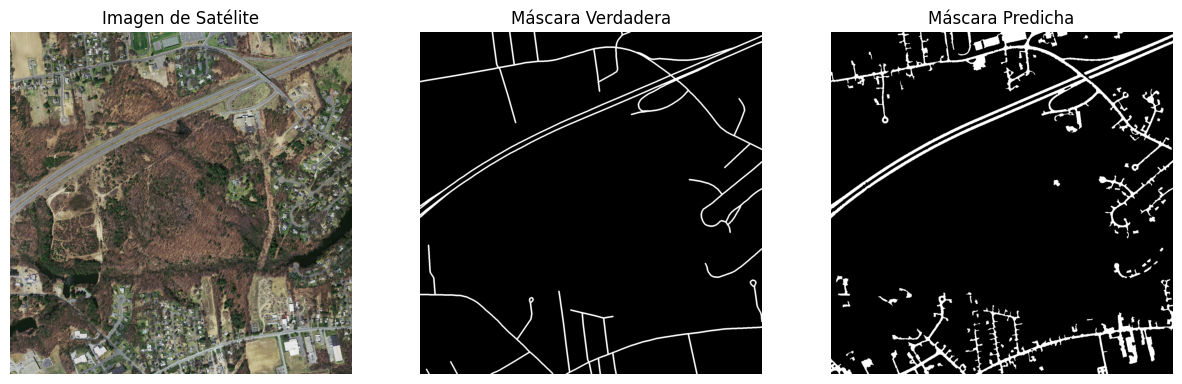

Modelo: HGB_d10_lr0.1_it200


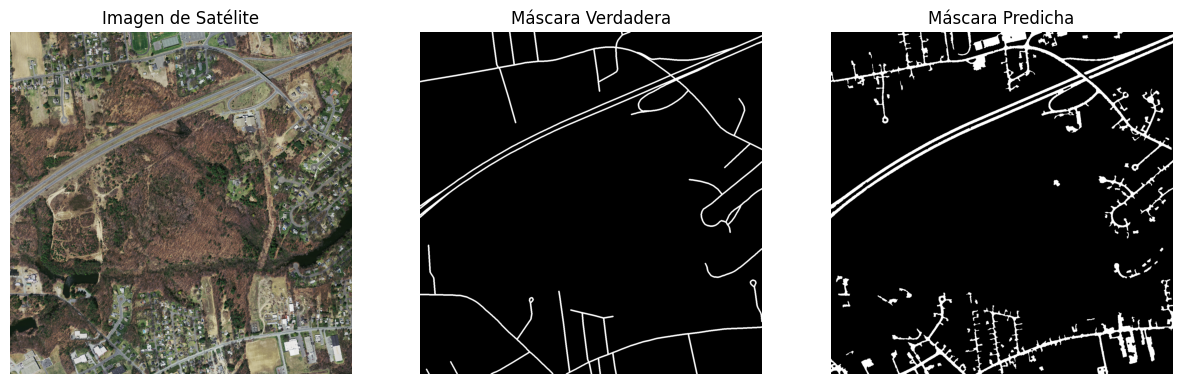

Modelo: HGB_d10_lr0.05_it300


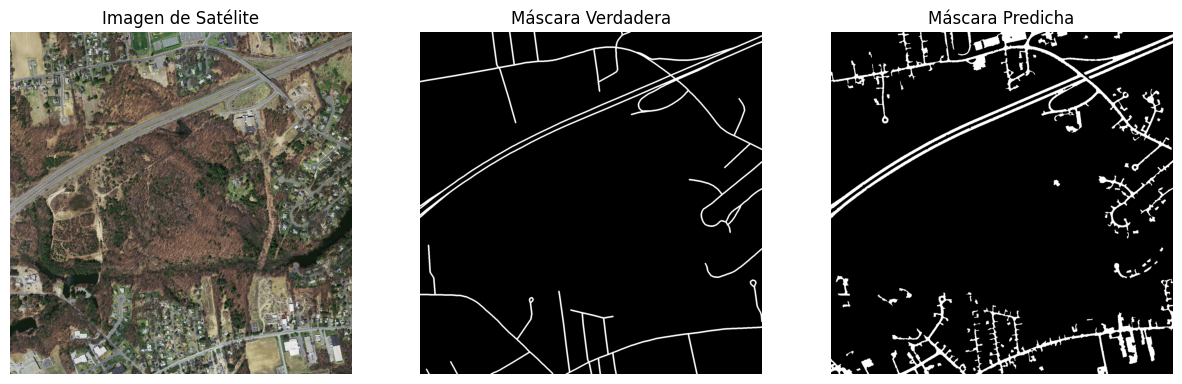

Modelo: HGB_d12_lr0.05_it300


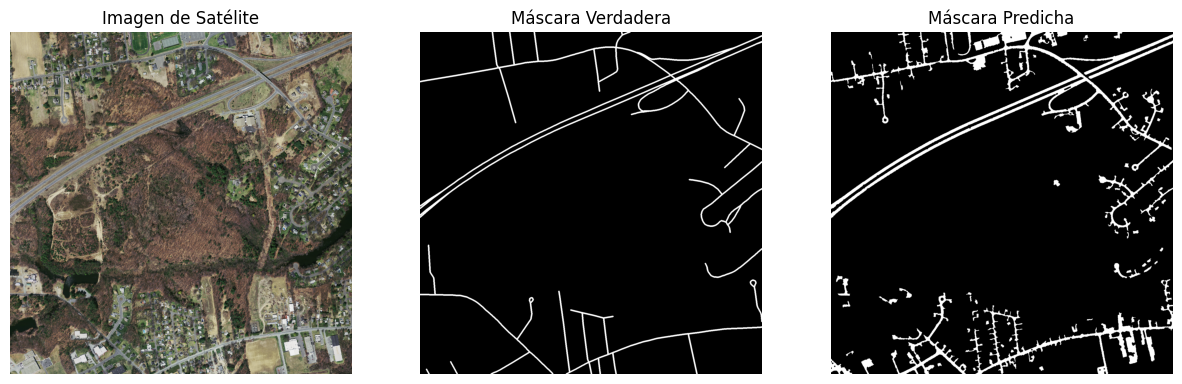

In [20]:
idx = 0

sat_image = sat_test[idx]
gt_mask   = gt_test[idx]

# Preparamos la imagen en formato batch (1, H, W, 3)
sat_batch = sat_image[None, ...]

# Extraemos features de ESA imagen
feature_maps_img = extract_features(sat_batch)

# Construimos X solo para esa imagen
X_img, _ = build_dataset(feature_maps_img, gt_mask[None, ...], FEATURE_LIST)

for info in all_model_results:
    model = info["model"]
    model_name = info["name"]
    # Predicción por píxel
        
    print(f"Modelo: {model_name}")

    y_pred = model.predict(X_img)

    # Reconstruimos la máscara
    pred_mask = y_pred.reshape(gt_mask.shape)

    # Postprocesamos la máscara
    pred_mask_pp = postprocess_mask(pred_mask, min_size=100, radius=3)

    visualize_results(sat_image, gt_mask, pred_mask_pp)

# Tabla resumen de resultados

In [21]:
df_resultados = pd.read_csv("resultados_nuevo_balanceo_post_agresivo_FEATURES_extendidas.csv")
df_resultados


,Modelo,Accuracy,Precision,Recall,Dice (F1),Jaccard
0,RF_n100_d10,0.938279,0.291708,0.765626,0.422458,0.267795
1,RF_n200_d10,0.938706,0.293338,0.765709,0.424177,0.269178
2,RF_n200_d15,0.934327,0.286341,0.822479,0.424793,0.269674
3,RF_n300_d15,0.934352,0.286344,0.821951,0.424726,0.269621
4,HGB_d8_lr0.1_it200,0.932697,0.280867,0.822034,0.418682,0.264768
5,HGB_d10_lr0.1_it200,0.933080,0.282086,0.821808,0.420005,0.265827
6,HGB_d10_lr0.05_it300,0.932713,0.280860,0.821634,0.418622,0.264719
7,HGB_d12_lr0.05_it300,0.932754,0.281117,0.822479,0.419017,0.265036
